# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

In [1]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader, Subset

from model.helpers import collate_fn

# Same dataset setup style as train.py
root = "/Users/nikan/Desktop/PersonalProjects/Notarius/datasets"
train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=True)

small_train_ds = Subset(train_ds, range(200))

# Apply collate function through DataLoader
train_loader = DataLoader(
    small_train_ds,
    batch_size=12,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)


Batch size: 12
Input lengths (first 5): [1278, 773, 1262, 1660, 222]
Target lengths (first 5): [176, 101, 180, 249, 17]
Original audio length (sample 2): 1262 frames


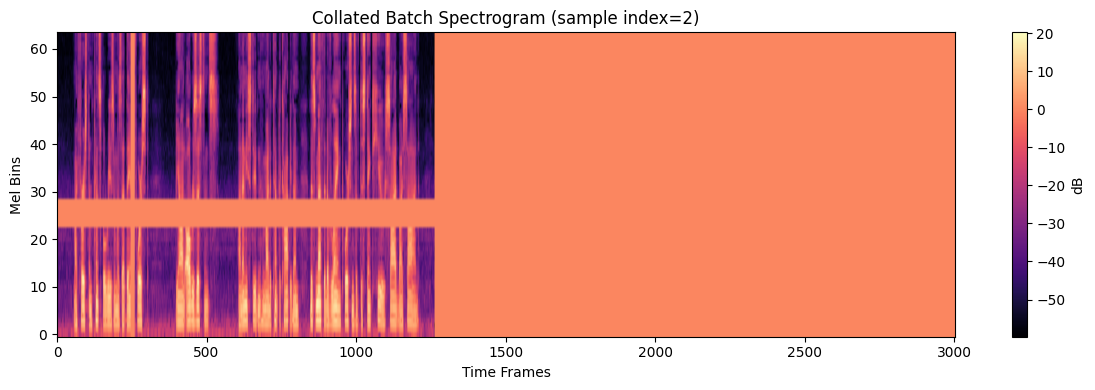

In [15]:
# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (time, n_mels)

# No padding now: true length only
original_length = int(input_lengths[idx].item())
print(f"Original audio length (sample {idx}): {original_length} frames")

plt.figure(figsize=(12, 4))
plt.imshow(spec, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx})")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()